# **Trabalho de Aprendizagem Computacional 1**

**Carlos Pereira (up202406988)**

**Maria Santos (up202404276)**



### **Objetivos**
Este trabalho teve como objetivo estudar o algoritmo do modelo de marchine learning Support Vector Machine, compreênde-lo, e propor modificações de forma a o tornar mais robusto a dados com outliers e ruido. Também implementamos uma pipeline de processamento com recurso a metafeatures para conseguirmos estudar o comportamento e performance do modelo e modificações na maioria dos datasets fornecidos para o trabalho.



-------------------------------------------------------------------------------




### **Modelo Escolhido: Support Vector Machine**

A Support Vector Machine (SVM) é um algoritmo clássico de aprendizado supervisionado que visa separar dados em diferentes classes através de um hiperplano ótimo. O objetivo principal do SVM é maximizar a margem de separação entre as classes, ou seja, aumentar ao máximo a distância entre o hiperplano e os pontos mais próximos de cada classe: os vetores de suporte. Desta forma, o modelo consegue uma melhor generalização e robustez na classificação de novos dados







---




### **Problemas que afetam o comportamento e performance dos SVMs**




Os SVMs são bastante sensiveis a dados com **outliers e ruido**, uma vez que vão distorcer o hiperplano e não permitir a classificação correta da maioria dos dados.

#### Como é que os **outliers** afetam os SVMs?

Os outliers presentes nos dados têm um impacto significativo na definição do hiperplano e na margem de separação. Como o algoritmo SVM tenta classificar corretamente todos os pontos, incluindo os outliers, o hiperplano ajusta-se para acomodar estes pontos anómalos. Este ajustamento desloca o hiperplano da sua posição ótima, alterando o seu declive e a ordenada na origem.

Como consequência deste deslocamento, muitos dos pontos normais (não-outliers) acabam mal classificados, pois o hiperplano já não se encontra na melhor posição para separar as classes. Os outliers "puxam" o hiperplano na sua direção, prejudicando a generalização do modelo nos dados normais.

Para mitigar este problema, utiliza-se o parâmetro de regularização **C**, que controla o equilíbrio entre maximizar a margem e permitir erros de classificação. Um valor de C mais baixo tolera mais erros (incluindo os causados por outliers), enquanto um C mais elevado tenta classificar todos os pontos corretamente.


#### Como é que o **ruído** afeta os SVMs?

Durante o processo de separação dos dados, o ruído pode encontrar-se dentro das margens de separação. O SVM tenta então classificar corretamente estes pontos ruidosos, o que força o algoritmo a reduzir a margem para os inlcuir numa das classes. Esta redução da margem compromete a capacidade de generalização do modelo, uma vez que diminui a "zona de segurança" entre as classes. O objetivo inicial é maximizar a distância de separação entre as classes, e não minimizá-la.


---



## **Código Base**

O SVM base foi retirado do repositório fornecido no enunciado. Juntamente com o modelo, retiramos também a classe Base Estimator e os Kernels linear e polinomial. Realtivamente ao kernel RBF fizemos implementação.




O **SMO** simplifica a otimização do SVM ao decompor o problema global em subproblemas mínimos, focando-se no ajuste de apenas dois multiplicadores de Lagrange (`alpha_i, alpha_j`) por iteração. Esta abordagem em pares é necessária para respeitar a restrição linear do modelo, onde a alteração de um ponto exige a compensação do outro para manter o equilíbrio.

Através da seleção de pares, o algoritmo atualiza iterativamente os multiplicadores de Lagrange.

# Modificações Propostas e Motivações:

As modificações propostas tiveram como intenção reduzir o peso dos outliers  e dos pontos de ruido na definição do hiperplano, através de várias alterações. Também quisemos explorar as metafeatures e o "DNA" do dataset, de forma a escolher o kernel mais adequado para cada dataset, para tentar maximizar a separabilidade dos dados e a performance dos vários modelos.


A primeira ideia que tivemos foi explorar o parâmetro de regularização C e como este tem impacto no peso que cada ponto tem na definição do hiperplano. O parâmetro C controla o equilíbrio entre maximizar a margem e penalizar os erros de classificação.

Relativamente à margem, o valor de C determina se um ponto será considerado um vetor de suporte ou não, uma vez que delimita se o multiplicador de lagrange vai levar a um ajuste do bias  

Um ponto torna-se um vetor de suporte quando se encontra dentro da margem ou é mal classificado (situações em que o seu multiplicador de Lagrange é positivo), satisfazendo as condições KKT de complementaridade.
Um valor mais elevado de C vai fazer com que o modelo e algoritmo tente classificar mais rigorosamente todos os pontos, tentando incluir os pontos que são outlies ( pontos de uma classe que tem valores associados a outras classes ) e o ruído, que normalmente se vai encontrar dentro da margem.

Por outro lado, um valor de C baixo permite mais erros de classificação,  uma margem mais larga e a uma maior generalização (pode levar ao underfitting). Usamos como valor padrão um C igual a 1.0.

Ao diminuirmos o C vamos fazer com que os pontos mais extremos não tenham impacto relevante para o calculo do bias e ajuste da posição, e ao mesmo tempo, o algoritmo não vai dar tanta importância ao ruído.

Ao tornar-se vetor de suporte, o ponto passa a ter peso no calculo do bias (b) e posição e orientação do hiperplano.




### **Implementação do C adaptativo**

A estratégia funciona em duas fases:



**Fase 1: Ajuste global de C baseado no ruído**

Esta seria a nossa proposta para tentar solucionar o problema do ruído.

Primeiro, o algoritmo verifica o `noise_factor` do dataset que está a avaliar, calculado durante o pré-processamento:
- Se `noise_factor` está entre 0.05 e 0.15 (ruído moderado): reduz C em 20% (`C = C * 0.80`)
- Se `noise_factor` é superior a 0.15 (ruído alto): reduz C em 50% (`C = C * 0.50`)
- Se `noise_factor` é baixo: mantém o C original

Os pontos ruído são pontos que vão estar em cima e dentro das margens de separação entre as classes.
Este ajuste global do parametro de regularização permite ao algoritmo "ignorar" estes pontos, fazendo com que tenham menos influencia na separação das classes e definição das margens.
Ao diminuir o C para os datasets que têm bastante noise, permitimos que o algoritmo tenha mais liberdade e leveza na classificação dos destes pontos, ou seja não os tente classificar corretamente, e continue a generalizar e a tentar maximizar as margens sem ter em conta estes pontos. Um C mais elevado vai levar a que modelo tente classificar mais rigorosamente os pontos.

Sem esta alteração, o algoritmo ia minimzar a margem de forma a tentar classificar corretamente estes pontos, enquanto que o nosso objetivo é maximizar a margem e a separação das classes.
Esta alteração do C é feita na função train, antes de todas as restantes modificações.  

O `noise_factor` é calculado no **processamento** e passado como **argumento nas modificações**.

**Fase 2: Cálculo de C individual por ponto**

Após a primeira passagem do algoritmo de treino (SMO), o modelo calcula um C individual para cada ponto, com base no erro de classificação. Os outliers vão ter erros maiores. Utilizamos a seguinte fórmula:

                        C_individual = C / (1 + abs(Erro[i]))


Guardamos estes valores, para numa fase seguinte, depois do treino terminar, refinarmos a equação do hiperplano com os Cs mais indicados.

Esta modificação tem como intenção recalcular um C menor para os pontos que são outliers, e que à partida vão ter um erro de classfiicação maior. Assim, o novo C seria mais reduzido, fazendo com que o modelo dê menos peso e importancia a estes pontos, e assim, que não tenham tanta influência no cálculo final do hiperplano.

**Backtrack**

Temos ainda uma verificação de **backtrack**:
Se o erro piorou: os multiplicadores são revertidos aos valores anteriores, descartando o ajustamento feito com `C_individual`.
Esta verificação permite manter a estabilidar e evitar atualizações destrutivas ou que piorem o erro de classificação.



Além disto, no **pré processamento**, procuramos encontrar qual é o **kernel mais adequado** ( `best kernel`) para separar os dados em cada dataset, de acordo com as suas caracteristicas intrinsecas, utilizando as metafeatures para esta seleção. Incorporamos o **kernel como argumento** do SVM base e nas modificações.
Esta ideia foi uma forma de explorar-mos o conceito dos kernels, perceber como cada funciona e para que tipo de dados são mais adequados, e de certa forma, tentar maximizar a perfomance dos modelos.

**KKT - Heuristica**

Temos também presente uma heuristica que não está incluida no SVM base: verificação da violação das condições **Karush-Kuhn-Tucker**.
As condições **KKT** atuam como o critério de paragem local garantindo que o SMO apenas despenda esforço computacional em pontos que efetivamente contribuem para o refinamento da margem. Otimizar na medida em que vai garantir que apenas utilizamos pontos não estão bem classificados, permitindo uma convergência mais rápida.

Retiramos esta adição ao código de várias fontes, mas deixo referenciado um artigo que inclui uma explicação simples sobre esta heuristica:

[Sequential Minimal Optimization: A Fast Algorithm for Training Support Vector Machines, John C. Platt, 1998](https://www.microsoft.com/en-us/research/wp-content/uploads/1998/04/sequential-minimal-optimization.pdf)



### **Vetorização do cálculo do Erro de Classificação**

A vetorização reduziu o overhead computacional e melhorou a eficiência prática através de operações otimizadas em NumPy, embora a complexidade assintótica permaneça aproximadamente O(n**2).

        predictions = np.dot(self.alpha * self.y, self.K) + self.b
        errors = predictions - self.y


No modelo base, calculamos sequencialmente, num  while loop os erros de classificação:

    while iters < self.max_iter:  # Iterações (constante, max_iter)
      for j in range(self.n_samples):  # Loop sobre n_samples
          i = self.random_index(j)  # atribuir um i ao j de forma random
          e_i, e_j = self._error(i), self._error(j)



**Estas modificações são tranversais a todos os modelos que modificamos, Modified 1 e 2.**



---
## **Modified 1**

Este modelo implementa o que referimos anteriormente. Além disso, neste modified implementamos também uma heuristica que permite escolher pares de pontos que otimizam e maximizam o salto de aprendizagem:

     mask = np.arange(self.n_samples) != i
     j = np.where(mask)[0][np.argmax(np.abs(Ei - errors[mask]))]
     | E_i - E_j |

Esta heuristica também tem como motivação/origem o artigo referenciado acima ([Sequential Minimal Optimization: A Fast Algorithm for Training Support Vector Machines, John C. Platt, 1998](https://www.microsoft.com/en-us/research/wp-content/uploads/1998/04/sequential-minimal-optimization.pdf)).

Esta heuristica selecionar o segundo multiplicador que maximiza o tamanho do passo de aprendizagem. Como calcular o passo exato seria demorado, o algoritmo usa a magnitude da diferença de erro |E_1 - E_2| como uma aproximação para garantir que cada iteração resulte no maior progresso possível.

Na implementação original escolhemos um par i j de forma aleatória


            (i = self.random_index(j)   #ESCOLHA RANDOM)
  


**Implementação do Modified 1:**

```
class SVM_modified_1(BaseEstimator):
    def __init__(self, C=1.0, kernel=None, tol=1e-3, max_iter=100, noise_factor=0):
        self.C = C
        self.tol = tol
        self.max_iter = max_iter
        self.noise_factor=noise_factor # calculado no pre processing utilizando o DNA

        self.kernel=kernel

        self.b = 0
        self.alpha = None
        self.K = None

    def fit(self, X, y=None):
        self._setup_input(X, y)
        self.K = np.zeros((self.n_samples, self.n_samples))
        for i in range(self.n_samples):
            self.K[:, i] = self.kernel(self.X, self.X[i, :])
        self.alpha = np.zeros(self.n_samples)
        self.sv_idx = np.arange(0, self.n_samples)
        return self._train()

    def _train(self):
        self._run_smo(adaptive_C=False)
        #NOVA ALTERAÇÃO
        if self.noise_factor> 0.05 and self.noise_factor< 0.15: #noise moderado
          self.C = self.C * 0.80
        else:
          if self.noise_factor>0.15: #noise alto
            self.C = self.C * 0.50

        # Calcular erros após 1ª passagem e ajustar C por ponto
        self.C_individual = np.array([
            self.C / (1.0 + abs(self._error(i)))
            for i in range(self.n_samples)
        ])

        self._run_smo(adaptive_C=True)

    def _run_smo(self, adaptive_C=False):
            iters = 0
            while iters < self.max_iter:
                iters += 1
                alpha_prev = np.copy(self.alpha)

                # --- VETORIZAÇÃO DOS ERROS ---
                # Calcula f(x) e erros para todas as amostras de uma vez
                predictions = np.dot(self.alpha * self.y, self.K) + self.b
                errors = predictions - self.y

                for i in range(self.n_samples):
                    Ci = self.C_individual[i] if adaptive_C else self.C
                    Ei = errors[i]
                    
                    # Verifica se o ponto i viola as condições KKT
                    if (self.y[i] * Ei < -self.tol and self.alpha[i] < Ci) or \
                    (self.y[i] * Ei > self.tol and self.alpha[i] > 0):

                        # Heurística de seleção para j (máxima diferença de erro)
                        mask = np.arange(self.n_samples) != i
                        j = np.where(mask)[0][np.argmax(np.abs(Ei - errors[mask]))]
                        
                        Ej = errors[j]
                        Cj = self.C_individual[j] if adaptive_C else self.C

                        # Cálculo do eta
                        eta = 2.0 * self.K[i, j] - self.K[i, i] - self.K[j, j]
                        if eta >= 0:
                            continue

                        L, H = self._find_bounds(i, j, Ci, Cj)
                        alpha_io, alpha_jo = self.alpha[i], self.alpha[j]

                        # Update alpha j
                        self.alpha[j] -= (self.y[j] * (Ei - Ej)) / eta
                        self.alpha[j] = self.clip(self.alpha[j], H, L)
                        
                        # Update alpha i
                        self.alpha[i] = self.alpha[i] + self.y[i] * self.y[j] * (alpha_jo - self.alpha[j])
                        self.alpha[i] = self.clip(self.alpha[i], Ci, 0)

                        # ---- Backtrack se o erro piorou ----
                        if adaptive_C:
                            # Cálculo pontual para o backtrack
                            e_j_depois = (self.alpha * self.y) @ self.K[:, j] + self.b - self.y[j]
                            if abs(e_j_depois) > abs(Ej):
                                self.alpha[i], self.alpha[j] = alpha_io, alpha_jo
                                continue

                        # Update bias
                        b1 = (self.b - Ei - self.y[i] * (self.alpha[i] - alpha_io) * self.K[i, i] -
                            self.y[j] * (self.alpha[j] - alpha_jo) * self.K[i, j])
                        b2 = (self.b - Ej - self.y[j] * (self.alpha[j] - alpha_jo) * self.K[j, j] -
                            self.y[i] * (self.alpha[i] - alpha_io) * self.K[i, j])

                        if 0 < self.alpha[i] < Ci:
                            self.b = b1
                        elif 0 < self.alpha[j] < Cj:
                            self.b = b2
                        else:
                            self.b = 0.5 * (b1 + b2)
                        
                        # Atualiza o vetor de erros localmente para a próxima iteração do loop i
                        predictions = np.dot(self.alpha * self.y, self.K) + self.b
                        errors = predictions - self.y

                    diff = np.linalg.norm(self.alpha - alpha_prev)
                    if diff < self.tol:
                        break

            logging.info("Convergence has reached after %s." % iters)
            self.sv_idx = np.where(self.alpha > 0)[0]

    def _predict(self, X=None):
        n = X.shape[0]
        result = np.zeros(n)
        for i in range(n):
            result[i] = np.sign(self._predict_row(X[i, :]))
        return result

    def _predict_row(self, X):
        k_v = self.kernel(self.X[self.sv_idx], X)
        return np.dot((self.alpha[self.sv_idx] * self.y[self.sv_idx]).T, k_v.T) + self.b

    def clip(self, alpha, H, L):
        if alpha > H:
            alpha = H
        if alpha < L:
            alpha = L
        return alpha

    def _error(self, i):
        return self._predict_row(self.X[i]) - self.y[i]

    def _find_bounds(self, i, j, Ci, Cj):
        if self.y[i] != self.y[j]:
            L = max(0, self.alpha[j] - self.alpha[i])
            H = min(Cj, Ci - self.alpha[i] + self.alpha[j])
        else:
            L = max(0, self.alpha[i] + self.alpha[j] - Ci)
            H = min(Cj, self.alpha[i] + self.alpha[j])
        return L, H

    def random_index(self, z):
        i = z
        while i == z:
            i = np.random.randint(0, self.n_samples)
        return i
```



---


## **Modified 2**

Modelo com a vetorização dos erros, mas sem a heuristica. Mantemos a escolha aleatória de pontos para otimizar.

             (i = self.random_index(j)   #ESCOLHA RANDOM)

Esta modificação surgiu do resultado da performance do modelo modified_1, que aplica a vetorização e a heurística, onde percebemos que o desempenho do modelo desceu comparativamente ao modelo base.

 A heurística de maximização do passo é greedy e foca-se apenas no par que parece dar o maior ganho imediato. No entanto, num espaço de erro complexo ou ruidoso como é o caso dos nossos datasets, este par pode estar sempre a "martelar" os mesmos pontos problemáticos, ignorando outros pontos que precisam de ajustes subtis para definir bem a fronteira.
 Ao escolher um j ao acaso, garantimos, ao longo de várias iterações, que todos os pares de pontos têm a oportunidade de ser otimizados. Isto permite que o algoritmo evite zonas de estagnação onde a heurística ficaria presa num ciclo repetitivo.

A escolha aleatória do par pode também funcionar como uma forma de robustez contra o ruído, evitando que o algoritmo se foque repetidamente nos mesmos pontos problemáticos.

Portanto optamos por fazer a seleção do j de forma aleatória, mas vetorizando os erros.


**Implementação**

```
class SVM_modified_2(BaseEstimator):
    def __init__(self, C=1.0, kernel=None, tol=1e-3, max_iter=100, noise_factor=0):
        self.C = C
        self.tol = tol
        self.max_iter = max_iter
        self.noise_factor=noise_factor # calculado no pre processing utilizando o DNA

        self.kernel=kernel

        self.b = 0
        self.alpha = None
        self.K = None

    def fit(self, X, y=None):
        self._setup_input(X, y)
        self.K = np.zeros((self.n_samples, self.n_samples))
        for i in range(self.n_samples):
            self.K[:, i] = self.kernel(self.X, self.X[i, :])
        self.alpha = np.zeros(self.n_samples)
        self.sv_idx = np.arange(0, self.n_samples)
        return self._train()

    def _train(self):
        self._run_smo(adaptive_C=False)
        #NOVA ALTERAÇÃO
        if self.noise_factor> 0.05 and self.noise_factor< 0.15: #noise moderado
          self.C = self.C * 0.80
        else:
          if self.noise_factor>0.15: #noise alto
            self.C = self.C * 0.50

        # Calcular erros após 1ª passagem e ajustar C por ponto
        self.C_individual = np.array([
            self.C / (1.0 + abs(self._error(i)))
            for i in range(self.n_samples)
        ])

        self._run_smo(adaptive_C=True)

    def _run_smo(self, adaptive_C=False):
            iters = 0
            while iters < self.max_iter:
                iters += 1
                alpha_prev = np.copy(self.alpha)

                # --- VETORIZAÇÃO DOS ERROS ---
                # Calcula f(x) e erros para todas as amostras de uma vez
                predictions = np.dot(self.alpha * self.y, self.K) + self.b
                errors = predictions - self.y

                for i in range(self.n_samples):
                    Ci = self.C_individual[i] if adaptive_C else self.C
                    Ei = errors[i]
                    
                    # Verifica se o ponto i viola as condições KKT
                    if (self.y[i] * Ei < -self.tol and self.alpha[i] < Ci) or \
                    (self.y[i] * Ei > self.tol and self.alpha[i] > 0):

                        # Heurística de seleção para j (máxima diferença de erro)
                        mask = np.arange(self.n_samples) != i
                        j = np.where(mask)[0][np.argmax(np.abs(Ei - errors[mask]))]
                        
                        Ej = errors[j]
                        Cj = self.C_individual[j] if adaptive_C else self.C

                        # Cálculo do eta
                        eta = 2.0 * self.K[i, j] - self.K[i, i] - self.K[j, j]
                        if eta >= 0:
                            continue

                        L, H = self._find_bounds(i, j, Ci, Cj)
                        alpha_io, alpha_jo = self.alpha[i], self.alpha[j]

                        # Update alpha j
                        self.alpha[j] -= (self.y[j] * (Ei - Ej)) / eta
                        self.alpha[j] = self.clip(self.alpha[j], H, L)
                        
                        # Update alpha i
                        self.alpha[i] = self.alpha[i] + self.y[i] * self.y[j] * (alpha_jo - self.alpha[j])
                        self.alpha[i] = self.clip(self.alpha[i], Ci, 0)

                        # ---- Backtrack se o erro piorou ----
                        if adaptive_C:
                            # Cálculo pontual para o backtrack
                            e_j_depois = (self.alpha * self.y) @ self.K[:, j] + self.b - self.y[j]
                            if abs(e_j_depois) > abs(Ej):
                                self.alpha[i], self.alpha[j] = alpha_io, alpha_jo
                                continue

                        # Update bias
                        b1 = (self.b - Ei - self.y[i] * (self.alpha[i] - alpha_io) * self.K[i, i] -
                            self.y[j] * (self.alpha[j] - alpha_jo) * self.K[i, j])
                        b2 = (self.b - Ej - self.y[j] * (self.alpha[j] - alpha_jo) * self.K[j, j] -
                            self.y[i] * (self.alpha[i] - alpha_io) * self.K[i, j])

                        if 0 < self.alpha[i] < Ci:
                            self.b = b1
                        elif 0 < self.alpha[j] < Cj:
                            self.b = b2
                        else:
                            self.b = 0.5 * (b1 + b2)
                        
                        # Atualiza o vetor de erros localmente para a próxima iteração do loop i
                        predictions = np.dot(self.alpha * self.y, self.K) + self.b
                        errors = predictions - self.y

                    diff = np.linalg.norm(self.alpha - alpha_prev)
                    if diff < self.tol:
                        break

            logging.info("Convergence has reached after %s." % iters)
            self.sv_idx = np.where(self.alpha > 0)[0]

    def _predict(self, X=None):
        n = X.shape[0]
        result = np.zeros(n)
        for i in range(n):
            result[i] = np.sign(self._predict_row(X[i, :]))
        return result

    def _predict_row(self, X):
        k_v = self.kernel(self.X[self.sv_idx], X)
        return np.dot((self.alpha[self.sv_idx] * self.y[self.sv_idx]).T, k_v.T) + self.b

    def clip(self, alpha, H, L):
        if alpha > H:
            alpha = H
        if alpha < L:
            alpha = L
        return alpha

    def _error(self, i):
        return self._predict_row(self.X[i]) - self.y[i]

    def _find_bounds(self, i, j, Ci, Cj):
        if self.y[i] != self.y[j]:
            L = max(0, self.alpha[j] - self.alpha[i])
            H = min(Cj, Ci - self.alpha[i] + self.alpha[j])
        else:
            L = max(0, self.alpha[i] + self.alpha[j] - Ci)
            H = min(Cj, self.alpha[i] + self.alpha[j])
        return L, H

    def random_index(self, z):
        i = z
        while i == z:
            i = np.random.randint(0, self.n_samples)
        return i

```



# **Pré Processamento**

## **Pipeline de Processamento**: Objetivo
- Automatizamos o tratamento dos dataset benchmark.


### **Problemas tratados por SVMs**

**Funções de Processamento:**

 **best_kernel()**

Objetivo:

O objetivo principal desta pipeline é ler os datasets fornecidos e, ao invés de personalizar o
processamento para cada dataset, automatizar a redução de dimensionalidade (eliminar
atributos sem variância que consomem recursos computacionais sem favorecer a capacidade
preditiva do modelo), normalizar os atributos quantitativos e codificar as variáveis
categóricas (recorrendo à API do OpenML) e preencher missing values ou eliminar colunas
completamente vazias.
1. Datasets com elevada dimensionalidade
2. Datasets com má separação linear
3. Datasets com muito noise (atributos sem variabilidade de resultados)
4. Datasets ricos em outliers


Condições:
De acordo com o artigo A Pratical Guide to Support Vector Classification (Hsu, Chang, Lin)
(2003), os kernels explorados nesta implementação (linear, polinomial, gaussiano) são
favoráveis às seguintes condições:
**Kernel linear:**

K(xi, xj) = x
T
i ∗ xj

**Kernels não-lineares:**

Parâmetro gamma é um peso que distingue a importância das amostras num espaço de
maior dimensionalidade. Aumentar gamma diminui o impacto dos pontos distantes da
região de separação na definição do hiperplano, o que favorece overfitting e limites restritos
na escolha de vetores de suporte (hard-margin)

[1]
O dataset linear ideal é grande (elevado número de registos) e linearmente separável
(hiperplano em R2).
Se o dataset for pequeno e existir sobreposição de classes, 2 coisas podem acontecer:
1. SVM com limites flexíveis (soft-margin) : introdução de slack variable, uma extensão
da margem, que permite classificação incorreta de pontos. Por causa disso, balance
accuracy diminui. Se mais pontos são considerados vetores de suporte, o tempo de
computação para _predict_row aumenta, porque vai ter de iterar por mais índices.
2. Convergência não é atingida, não há solução para o problema de otimização e o loop
em run_smo continua até atingir o máximo de iterações permitido.
Datasets com class imbalance

**Polinomial:**
 K(xi, xj) = (γ ∗ x
T
i ∗ xj + r)
d
, γ > 0.

Datasets grandes onde o número de datapoints é maior do que o número de atributos .
Depend
Datasets com n_inst<<n_attrib ou datasets com muitas colunas redundantes (noise) são
problemáticas para o kernel polinomial. Porquê?
Gaussiano / Radial Basis Function: K(xi, xj) = exp(−γ ∗ ||xi − xj||
2), γ > 0


**Notas sobre datasets categóricos**

Regras de ruído e dimensionalidade

Preenchimento de Missing Values

**Normalização (scaling)**

O cálculo da distância euclidiana e a natureza exponencial da função construtora da
matriz kernel aumenta a penalização a pontos isolados (outliers).

O dataset pequeno, heterogéneo e com poucos outliers é o mais adequado para a
função RBF.

Por causa da complexidade temporal do algoritmo (O(n^2)), datasets com muitas
amostras são pouco adequados ao problema. Datasets maioritariamente categóricos são
particularmente inadequados, porque
O dicionário de metafeatures criado com .metafeatures_extraction() gera um score
para 4 problemas possíveis.

Cada score foi normalizado para um intervalo de [0, 1] , de maneira a que a
importância atribuída a cada problema dependa apenas dos pesos dados por kernel.
Ranked problemas retorna uma lista de dicionários com o modelo kernel, respetivos
pesos e o score obtido para o dataset.
O kernel escolhido para processar o dataset atual é o que tiver maior "weighted score".

Datasets categóricos como dataset3 seguem uma distribuição Bernoulli.

Metafeatures como kurtosis, skewness e a performance do modelo LDA sklearn
(discriminante linear de Fisher) estão dependentes da média e variância — não são
relevantes para datasets maioritariamente categóricos.
Se o dataset for constituído por mais de 80% atributos categóricos, ignoramos as
métricas dependentes de média e variância, porque foram inflacionadas pelo encoding.
Escolhemos a computação da média e desvio padrão com nanmean , nansd para
computar a média dos atributos onde não existem valores nan .
O dataset_38 tem 2 problemas: maioria dos atributos são categóricos e alguns são
totalmente preenchidos por NaNs — a coluna é eliminada.

SVMs são sensíveis a elevada dimensionalidade.
Não removemos todos os atributos redundantes, mas colunas com 0 variância (1 valor
distinto na coluna) apenas aumentam o custo computacional → **check_noise_column** .

Atributos categóricos: preenchimento com a moda.
Atributos numéricos: preenchimento com o valor do vizinho mais próximo
( KNN_imputer ).

**Normalização da escala de valores possíveis para atributos preditivos.**


.metafeatures_extraction()
Objetivo: Avaliar a distribuição original dos dados do dataset, pré-processamento.
Se não fizermos antes do processamento, métricas de outliers como kurtosis serão
enviesadas.
Metafeatures calculadas

Metafeature Descrição
nr_inst Number of instances/registos no dataset (n)
nr_attr Number of attributes/features no dataset (p)
outliers Proporção ou contagem de outliers para uma feature x_i ou target y
iq_range Intervalo interquartil
skewness Assimetria estatística
kurtosis Curtose estatística
linear_discr Performance do algoritmo de discriminação linear (LDA) com o dataset
mut_inf Mutual Information — relação entre feature independente x_i e target y

Fórmulas aplicadas

Módulo cat_attrib (./sources)

Verificação do Processamento
Usamos o sklearn.StandardScaler(), que pressupõe que as variáveis são contínuas, com
distribuição aproximável à distribuição Normal. Datasets inteiramente categóricos são
ignorados pelo algoritmo de modo a diminuir custo computacional redundante.

"low_separability": 0.0 if highly_categorical else 1.0 - min(linear_discr,
1.0)
"outlier_heavy": 0.0 if highly_categorical else min((abs(kurtosis) +
skewness) / 10.0, 1.0)

Utilizando a API do OpenML, retiramos apenas os metadados do dataset.
Listamos os atributos categóricos para dummy_encoding na função
one_hot_encoding() .

Para identificar possíveis erros lógicos, definimos blocos try/except com assert .


**Atributos da Classe Dataset
(definição completa omitida — ver código fonte)**
NOTA: Obtemos um agrupamento de datasets por tipo de problema, tornando as
adaptações às soluções gerais já apresentadas mais específicas aos datasets.

**Parâmetro Sigma (Kernel RBF)**

Valor de sigma Efeito~

- Baixo Torna o modelo sensível a padrões locais
- Elevado Generaliza, diminuindo o efeito de overfitting do noise

**Função Kernel**

**Distinção entre Fisher LDA e Fisher Discriminant Ratio (F1-Score)**

Conceito Descrição

F1-Score Sobreposição geométrica das distribuições de classe no espaço de features.
Formulação hipotética da separação de classes, independentemente do
modelo utilizado.

Fisher
LDA

Medida da performance (exatidão preditiva) de um modelo de separação
linear de dados. Selecionando um modelo, medimos a performance.

**KKT Conditions no SMO Pipeline**

Garante que não existem colunas com NaN values depois de KNN_NaN_Filling , (...) →
change_log_9 .

Objetivo: Computação implícita dos produtos de vetores num espaço de
dimensionalidade menor para um espaço de dimensionalidade maior.
A função kernel separa os dados sem executar a computação dos vetores no espaço de
maior dimensionalidade.

A metafeature mais relevante para a escolha do kernel linear é a landmark LDA
(Discriminante Linearidade de Fisher) do Pymfe.
Esta função projeta o espaço de atributos num espaço de menor dimensionalidade,
avaliando simultaneamente a performance de distinção das classes quando o
hiperplano é apenas uma reta.


**Quando um ponto não satisfaz KKT:**

**Pontos Candidatos**

**Condição de alpha Requisito KKT**
alpha = 0 Se corretamente classificado, o ponto tem de estar fora da margem
0 < alpha < C Ponto tem de estar no limite da margem
KKT determina se o ponto de treino foi corretamente classificado e posicionado.
Condições ótimas obrigatoriamente satisfeitas.

1. Foi classificado incorretamente
2. Está dentro da margem

 Máquina de vetores de suporte, Remigio Matheus. Imagem de Albon, Chris. Influência do fator gamma
no efeito de overfitting e underfitting em espaços >R2 ↩︎



---
# **Métricas utlizadas para avaliação**

Neste contexto de datasets benchmark, reparamos em vários problemas além do noise e outliers. Alguns datasets também apresentam class imbalance. Por este motivo, optamos por avaliar o desempenho do modelo com a **Balanced Accuracy**.

A **balanced accuracy** tem em conta a accuracy das duas classes, e faz uma média ponderada:

        Balanced Accuracy = (Accuracy da classe A + Accuracy da classe B) / 2

Além desta métrica, avaliamos também com a precisão e o f1 score.

Iremos concluir e fazer o nosso teste estatistico da performance dos modelos modificados utilizando a balanced accuracy, pois netse contexto é a métrica mais fiável.





---



## **Resultados Esperados**

**Onde esperamos que o SVM_modified_1 tenha melhor desempenho:**

Datasets caracterizados por terem noise elevado, overlapping de classes e classe imbalance, cujo kernel selecionado é op kbf (high ns_ratio, high kurtosis/skewness).   

Porquê?

A seleção aleatória do par de pontos a otimizar evita a fixação do modelo em pontos perto de regiões de ruído.
O mecanismo de backtrack também contribui para esta robustez contra o ruído.


**Onde esperamos que o SVM_modified_2 tenha melhor desempenho?**

Datasets com estrutura clara, pouco ruido, e complexos mas com uma fronteira de decisão bem definida. Dados com muitos outliers, pouco ruído (High outlier_heavy + low ns_ratio).

A Heuristica determinística é uma vantagem mais significativa quando a maioria dos pontos violam as condições KKT e são informativos do que quando o dataset tem muito ruído.

O algoritmo converge mais rápido devido à agressividade da escolha dos pares, em datasets com dimensionalidade alta e pouco ruído, e em que normalmente é atribuido o kernel polinomial.




---



# **Avaliação da perfomance dos modelos modificados**

#**Mean Performance (Friedman + Bonferroni-Dunn)**




### **Performance Evaluation pipeline**


**Mean Performance (Friedman + Bonferroni-Dunn)**

Fonte: https://github.com/benjaminpatrickevans/MethodComparisonsInPython


Existem 2 hipóteses nulas

Rank: classificação ordenada da performance dos modelos para cada dataset. O melhor modelo tem rank=1, o segundo melhor rank=2 , etc. Friedman é um teste estatísitco da distribuição destes ranks no conjunto de datasets.
Analisamos o desvio do rank médio em relação ao valor base 2.0.

A performance dos modelos em datasets individuais pode ser drasticamente diferente. Com o teste de Friedman procuramos não a análise individual da performance, mas sim  padrões sistemáticos da performance. Se o ranking médio for 2.0, Friedman não rejeita H0.

H0 (Friedman): Os modelos SVM_STANDARD, modified_3 e modified_3.1 têm médias iguais de ranks nos 50 datasets. Nenhum modelo é sistematicamente melhor do que os restantes.

	H0 (Friedman) : Rank(STANDARD)=Rank(modified_3)=R(modified_3.1)=2.0, para ranks[1,2,3].

H1: Existe pelo menos 1 modelo com rank médio sistematicamente diferente dos restantes.


H0 (Bonferroni): Se e só se Friedman rejeitar H0 é que podemos verificar se a mesma hipótese é rejeitável para cada par: (STANDARD, MODIFIED_3) e (STANDARD, MODIFIED_3.1)

	Ho(Bonferroni) :  | R(STANDARD) - R(MODIFIED) | < CD. Se não for rejeitável, então não existe diferença.

Estes foram os resultados obtidos:

Friedman: rejeitamos a hipótese nula com 95.0 % confiança. Existe pelo menos um modelo com rank suficiente distinto.


Bonferroni-Dunn:
SVM_STANDARD vs SVM_modified_3
|R(baseline) - R(challenger)| = 1.0000  CD=0.4891

H0 (STANDARD_MODIFIED_3) foi rejeitado. No SVM_STANDARD VS SVM_modified_3, SVM_STANDARD é o modelo superior: 1.

7142857142857142,2.7142857142857144
SVM_STANDARD vs SVM_modified_3.1
|R(baseline) - R(challenger)| = 0.1429  CD=0.4891
Não existe diferença sistemática de rank entre o modelo SVM_modified_3 e standard.




In [ ]:
from sources import eval_analysis

eval_analysis.__main__()

# Qual é o kernel mais utilizado?

In [ ]:
#.1 Qual é o kernel mais utlizado

for file in os.scandir(final_eval_path):
    df = pd.read_csv(file.path)
    kernel_column: pd.Series = df["Kernel Function"]
    counts = kernel_column.value_counts()

    freq = counts.values  # Equivalent to np.array(counts)
    labels = counts.index
    plt.title("Frequência relativa das funções Kernel")
    plt.pie(freq, labels=labels,autopct='%1.1f%%')

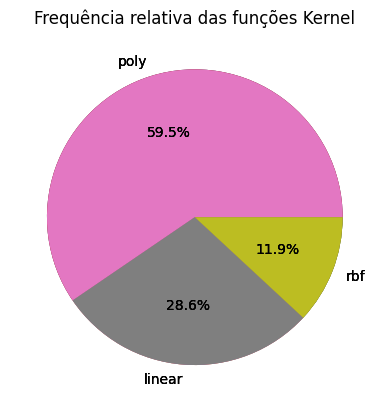

# Performance para datasets individuais

Podemos analisar com mais detalhe os 3 ficheiros de performance gerados. O método implementado determina qual foi o modelo que teve a melhor resposta para cada métrica e para cada dataset.

Os SVM_modified_3 e o SVM_modified_3.1 correspondem ao modified 1 e modified 2, respetivamente, abordados neste jupyter.

Este foi o output gerado:

In [ ]:

from sources import eval_analysis
eval_analysis.winner_by_dataset()

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Dataset</th>
      <th>best_model_Balanced Accuracy</th>
      <th>best_score_Balanced Accuracy</th>
      <th>best_model_F1-Score (Macro)</th>
      <th>best_score_F1-Score (Macro)</th>
      <th>best_model_Precision</th>
      <th>best_score_Precision</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>dataset_13_breast-cancer.csv</td>
      <td>SVM_STANDARD</td>
      <td>0.6037</td>
      <td>SVM_STANDARD</td>
      <td>0.6590</td>
      <td>SVM_modified_3.1</td>
      <td>0.7043</td>
    </tr>
    <tr>
      <th>1</th>
      <td>dataset_164_molecular-biology_promoters.csv</td>
      <td>SVM_STANDARD</td>
      <td>0.9445</td>
      <td>SVM_STANDARD</td>
      <td>0.9433</td>
      <td>SVM_STANDARD</td>
      <td>0.9466</td>
    </tr>
    <tr>
      <th>2</th>
      <td>dataset_25_colic.csv</td>
      <td>SVM_modified_3.1</td>
      <td>0.8217</td>
      <td>SVM_STANDARD</td>
      <td>0.8309</td>
      <td>SVM_modified_3.1</td>
      <td>0.8337</td>
    </tr>
    <tr>
      <th>3</th>
      <td>dataset_27_colic.csv</td>
      <td>SVM_modified_3.1</td>
      <td>0.7671</td>
      <td>SVM_modified_3.1</td>
      <td>0.7844</td>
      <td>SVM_modified_3.1</td>
      <td>0.7864</td>
    </tr>
    <tr>
      <th>4</th>
      <td>dataset_29_credit-approval.csv</td>
      <td>SVM_STANDARD</td>
      <td>0.7809</td>
      <td>SVM_STANDARD</td>
      <td>0.7876</td>
      <td>SVM_STANDARD</td>
      <td>0.7929</td>
    </tr>
    <tr>
      <th>5</th>
      <td>dataset_31_credit-g.csv</td>
      <td>SVM_STANDARD</td>
      <td>0.6590</td>
      <td>SVM_modified_3.1</td>
      <td>0.7205</td>
      <td>SVM_modified_3</td>
      <td>0.7401</td>
    </tr>
    <tr>
      <th>6</th>
      <td>dataset_333_monks-problems-1.csv</td>
      <td>SVM_modified_3.1</td>
      <td>0.7035</td>
      <td>SVM_modified_3.1</td>
      <td>0.6701</td>
      <td>SVM_modified_3.1</td>
      <td>0.7362</td>
    </tr>
    <tr>
      <th>7</th>
      <td>dataset_334_monks-problems-2.csv</td>
      <td>SVM_modified_3</td>
      <td>0.5039</td>
      <td>SVM_modified_3</td>
      <td>0.5397</td>
      <td>SVM_modified_3</td>
      <td>0.5145</td>
    </tr>
    <tr>
      <th>8</th>
      <td>dataset_335_monks-problems-3.csv</td>
      <td>SVM_modified_3.1</td>
      <td>0.9697</td>
      <td>SVM_modified_3.1</td>
      <td>0.9693</td>
      <td>SVM_modified_3.1</td>
      <td>0.9706</td>
    </tr>
    <tr>
      <th>9</th>
      <td>dataset_336_SPECT.csv</td>
      <td>SVM_STANDARD</td>
      <td>0.7125</td>
      <td>SVM_modified_3.1</td>
      <td>0.7850</td>
      <td>SVM_STANDARD</td>
      <td>0.8156</td>
    </tr>
    <tr>
      <th>10</th>
      <td>dataset_43_haberman.csv</td>
      <td>SVM_STANDARD</td>
      <td>0.5807</td>
      <td>SVM_modified_3.1</td>
      <td>0.6472</td>
      <td>SVM_STANDARD</td>
      <td>0.6920</td>
    </tr>
    <tr>
      <th>11</th>
      <td>dataset_444_analcatdata_boxing2.csv</td>
      <td>SVM_modified_3.1</td>
      <td>0.8288</td>
      <td>SVM_modified_3.1</td>
      <td>0.8320</td>
      <td>SVM_modified_3.1</td>
      <td>0.8405</td>
    </tr>
    <tr>
      <th>12</th>
      <td>dataset_448_analcatdata_boxing1.csv</td>
      <td>SVM_modified_3</td>
      <td>0.8011</td>
      <td>SVM_modified_3</td>
      <td>0.8218</td>
      <td>SVM_modified_3.1</td>
      <td>0.8318</td>
    </tr>
    <tr>
      <th>13</th>
      <td>dataset_450_analcatdata_lawsuit.csv</td>
      <td>SVM_STANDARD</td>
      <td>0.9255</td>
      <td>SVM_STANDARD</td>
      <td>0.9524</td>
      <td>SVM_STANDARD</td>
      <td>0.9648</td>
    </tr>
    <tr>
      <th>14</th>
      <td>dataset_451_irish.csv</td>
      <td>SVM_modified_3.1</td>
      <td>1.0000</td>
      <td>SVM_modified_3.1</td>
      <td>1.0000</td>
      <td>SVM_modified_3.1</td>
      <td>1.0000</td>
    </tr>
    <tr>
      <th>15</th>
      <td>dataset_461_analcatdata_creditscore.csv</td>
      <td>SVM_modified_3.1</td>
      <td>0.8486</td>
      <td>SVM_modified_3.1</td>
      <td>0.8651</td>
      <td>SVM_modified_3.1</td>
      <td>0.8921</td>
    </tr>
    <tr>
      <th>16</th>
      <td>dataset_463_backache.csv</td>
      <td>SVM_modified_3</td>
      <td>0.6155</td>
      <td>SVM_STANDARD</td>
      <td>0.8425</td>
      <td>SVM_modified_3.1</td>
      <td>0.8478</td>
    </tr>
    <tr>
      <th>17</th>
      <td>dataset_466_schizo.csv</td>
      <td>SVM_STANDARD</td>
      <td>0.5847</td>
      <td>SVM_STANDARD</td>
      <td>0.5738</td>
      <td>SVM_STANDARD</td>
      <td>0.5888</td>
    </tr>
    <tr>
      <th>18</th>
      <td>dataset_470_profb.csv</td>
      <td>SVM_modified_3.1</td>
      <td>0.6161</td>
      <td>SVM_modified_3.1</td>
      <td>0.6598</td>
      <td>SVM_modified_3.1</td>
      <td>0.6613</td>
    </tr>
    <tr>
      <th>19</th>
      <td>dataset_481_biomed.csv</td>
      <td>SVM_modified_3.1</td>
      <td>0.8597</td>
      <td>SVM_modified_3.1</td>
      <td>0.8617</td>
      <td>SVM_modified_3.1</td>
      <td>0.8718</td>
    </tr>
    <tr>
      <th>20</th>
      <td>dataset_49_heart-c.csv</td>
      <td>SVM_modified_3.1</td>
      <td>0.7588</td>
      <td>SVM_modified_3.1</td>
      <td>0.7633</td>
      <td>SVM_modified_3.1</td>
      <td>0.7687</td>
    </tr>
    <tr>
      <th>21</th>
      <td>dataset_50_tic-tac-toe.csv</td>
      <td>SVM_STANDARD</td>
      <td>0.9759</td>
      <td>SVM_STANDARD</td>
      <td>0.9832</td>
      <td>SVM_STANDARD</td>
      <td>0.9838</td>
    </tr>
    <tr>
      <th>22</th>
      <td>dataset_51_heart-h.csv</td>
      <td>SVM_STANDARD</td>
      <td>0.7646</td>
      <td>SVM_STANDARD</td>
      <td>0.7777</td>
      <td>SVM_STANDARD</td>
      <td>0.7881</td>
    </tr>
    <tr>
      <th>23</th>
      <td>dataset_55_hepatitis.csv</td>
      <td>SVM_modified_3.1</td>
      <td>0.7751</td>
      <td>SVM_modified_3.1</td>
      <td>0.8466</td>
      <td>SVM_modified_3.1</td>
      <td>0.8679</td>
    </tr>
    <tr>
      <th>24</th>
      <td>dataset_56_vote.csv</td>
      <td>SVM_modified_3</td>
      <td>0.9524</td>
      <td>SVM_modified_3</td>
      <td>0.9562</td>
      <td>SVM_modified_3</td>
      <td>0.9572</td>
    </tr>
    <tr>
      <th>25</th>
      <td>dataset_714_fruitfly.csv</td>
      <td>SVM_STANDARD</td>
      <td>0.5142</td>
      <td>SVM_STANDARD</td>
      <td>0.5213</td>
      <td>SVM_modified_3.1</td>
      <td>0.5491</td>
    </tr>
    <tr>
      <th>26</th>
      <td>dataset_719_veteran.csv</td>
      <td>SVM_STANDARD</td>
      <td>0.6315</td>
      <td>SVM_modified_3.1</td>
      <td>0.6651</td>
      <td>SVM_STANDARD</td>
      <td>0.6931</td>
    </tr>
    <tr>
      <th>27</th>
      <td>dataset_724_analcatdata_vineyard.csv</td>
      <td>SVM_modified_3.1</td>
      <td>0.7866</td>
      <td>SVM_modified_3.1</td>
      <td>0.7860</td>
      <td>SVM_STANDARD</td>
      <td>0.8236</td>
    </tr>
    <tr>
      <th>28</th>
      <td>dataset_738_pharynx.csv</td>
      <td>SVM_modified_3.1</td>
      <td>0.7886</td>
      <td>SVM_modified_3.1</td>
      <td>0.8081</td>
      <td>SVM_modified_3.1</td>
      <td>0.8279</td>
    </tr>
    <tr>
      <th>29</th>
      <td>dataset_741_rmftsa_sleepdata.csv</td>
      <td>SVM_modified_3.1</td>
      <td>0.6303</td>
      <td>SVM_modified_3.1</td>
      <td>0.6178</td>
      <td>SVM_modified_3.1</td>
      <td>0.6536</td>
    </tr>
    <tr>
      <th>30</th>
      <td>dataset_745_auto_price.csv</td>
      <td>SVM_modified_3.1</td>
      <td>0.8796</td>
      <td>SVM_modified_3.1</td>
      <td>0.8982</td>
      <td>SVM_modified_3.1</td>
      <td>0.9012</td>
    </tr>
    <tr>
      <th>31</th>
      <td>dataset_748_analcatdata_wildcat.csv</td>
      <td>SVM_STANDARD</td>
      <td>0.6360</td>
      <td>SVM_STANDARD</td>
      <td>0.7229</td>
      <td>SVM_STANDARD</td>
      <td>0.7418</td>
    </tr>
    <tr>
      <th>32</th>
      <td>dataset_757_meta.csv</td>
      <td>SVM_modified_3.1</td>
      <td>0.5306</td>
      <td>SVM_modified_3.1</td>
      <td>0.8500</td>
      <td>SVM_modified_3</td>
      <td>0.8445</td>
    </tr>
    <tr>
      <th>33</th>
      <td>dataset_764_analcatdata_apnea3.csv</td>
      <td>SVM_modified_3.1</td>
      <td>0.7626</td>
      <td>SVM_modified_3.1</td>
      <td>0.9152</td>
      <td>SVM_modified_3.1</td>
      <td>0.9301</td>
    </tr>
    <tr>
      <th>34</th>
      <td>dataset_765_analcatdata_apnea2.csv</td>
      <td>SVM_modified_3.1</td>
      <td>0.9101</td>
      <td>SVM_modified_3.1</td>
      <td>0.9465</td>
      <td>SVM_modified_3.1</td>
      <td>0.9514</td>
    </tr>
    <tr>
      <th>35</th>
      <td>dataset_767_analcatdata_apnea1.csv</td>
      <td>SVM_STANDARD</td>
      <td>0.8510</td>
      <td>SVM_modified_3.1</td>
      <td>0.9133</td>
      <td>SVM_STANDARD</td>
      <td>0.9291</td>
    </tr>
    <tr>
      <th>36</th>
      <td>dataset_771_analcatdata_michiganacc.csv</td>
      <td>SVM_modified_3.1</td>
      <td>0.7194</td>
      <td>SVM_modified_3.1</td>
      <td>0.6990</td>
      <td>SVM_modified_3.1</td>
      <td>0.7645</td>
    </tr>
    <tr>
      <th>37</th>
      <td>dataset_784_newton_hema.csv</td>
      <td>SVM_STANDARD</td>
      <td>0.8286</td>
      <td>SVM_STANDARD</td>
      <td>0.8274</td>
      <td>SVM_STANDARD</td>
      <td>0.8356</td>
    </tr>
    <tr>
      <th>38</th>
      <td>dataset_786_cleveland.csv</td>
      <td>SVM_STANDARD</td>
      <td>0.7227</td>
      <td>SVM_STANDARD</td>
      <td>0.7199</td>
      <td>SVM_STANDARD</td>
      <td>0.7356</td>
    </tr>
    <tr>
      <th>39</th>
      <td>dataset_796_cpu.csv</td>
      <td>SVM_STANDARD</td>
      <td>0.8945</td>
      <td>SVM_STANDARD</td>
      <td>0.9290</td>
      <td>SVM_STANDARD</td>
      <td>0.9385</td>
    </tr>
    <tr>
      <th>40</th>
      <td>dataset_798_cholesterol.csv</td>
      <td>SVM_STANDARD</td>
      <td>0.5542</td>
      <td>SVM_STANDARD</td>
      <td>0.5581</td>
      <td>SVM_modified_3.1</td>
      <td>0.5683</td>
    </tr>
    <tr>
      <th>41</th>
      <td>dataset_810_pbc.csv</td>
      <td>SVM_STANDARD</td>
      <td>0.6174</td>
      <td>SVM_STANDARD</td>
      <td>0.5960</td>
      <td>SVM_modified_3</td>
      <td>0.6484</td>
    </tr>
  </tbody>
</table>
</div>

In [ ]:
def graph_model(file):

    df = pd.read_csv(file)
    model_column: pd.Series = df["best_model_Balanced Accuracy"]
    counts = model_column.value_counts()

    freq = counts.values
    labels = counts.index
    plt.title("Frequência relativa dos datasets")
    plt.pie(freq, labels=labels, autopct='%1.1f%%')
    plt.show()

graph_model("winner_by_dataset.csv")

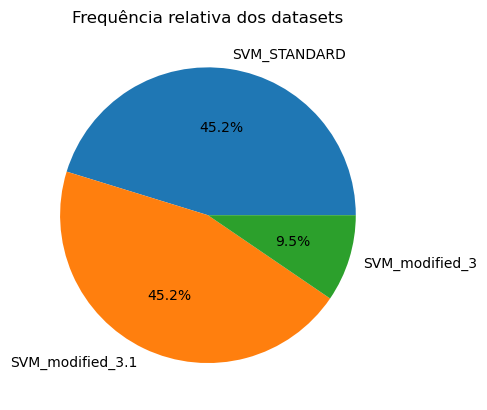

Analisando o gráfico vemos que o modified_1 teve uma performance melhor do que o SVM base em 19 dos datasets estudados (45.2%).

O facto de o Modified 1 ter tido uma performance menos alta pode dever-se à heuristica que escolhe o melhor passo, que como referido anteriormente, tem a desvantagem de fazer com que o algoritmo fique "preso" num conjunto de pontos, por vezes perto de zonas de ruído, o que não permite que otimize pontos que realmente contribuiriam para uma melhor classificação.

Os resultados do Modified 2 corroboraram a nossa hipotese de que a escolha aleatória de um par de multiplicadores para otimizar pode tornar o modelo mais robusto ao ruido.

Os restantes resultados que obtivemos podem ser justificados pelo facto de os datasets benchmark não terem apenas dados ricos em noise e outliers, mas também dados com class imbalance e pouca separabilidade. Para este problema, desenvolvemos a pipeline de pré processamento onde tentamos generalizar este processo para todos os datasets.



---


# **Conclusões**

As modificações propostas, apesar de não superarem o algoritmo base em alguns dos datasets benchmark, provaram tornar o SVM base mais robusto contra ruido e outliers, como era pretendido inicialmente. Ao alcançar resultados semelhantes ao SVM base, concluímos que a introdução de mecanismos de robustez não comprometeu a capacidade preditiva central do modelo original.

À parte do desafio principal de propôr alterações significativas ao modelo standard do SVM, desenvolvemos uma pipeline completamente automatizada para processamento de dados, eliminação de colunas redundantes, procurando utilizar metafeatures como heurística para a aproximação do kernel mais adequado. Os dados de performance gerados foram analisados recorrendo a técncias avançadas de avaliação empírica de algoritmos, com respetiva contextualização e distinção no âmbito das modificações realizadas.

